<a href="https://colab.research.google.com/github/Affanaf21/-231A023-_NLP-Experiments/blob/main/NLP_exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random

In [ ]:
nltk.download('twitter_samples')


[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print('Number of positive tweets:', len(positive_tweets))
print('Number of negative tweets:', len(negative_tweets))

print('\nThe type of all positive tweets:', type(positive_tweets))
print('\nThe type of a tweet entry is:', type(negative_tweets[0]))

Number of positive tweets: 5000
Number of negative tweets: 5000

The type of all positive tweets: <class 'list'>

The type of a tweet entry is: <class 'str'>


In [ ]:
positive_tweets[4]

'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days'

In [ ]:
negative_tweets[4]

'Dang starting next week I have "work" :('

In [ ]:
import pandas as pd
positive_tweets = pd.DataFrame(positive_tweets,columns=["Tweets"])
negative_tweets = pd.DataFrame(negative_tweets,columns=["Tweets"])

In [ ]:
positive_tweets['Sentiment'] = 'Positive'
positive_tweets.head()

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :),Positive
1,@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!,Positive
2,@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days,Positive


In [ ]:
negative_tweets['Sentiment'] = 'Negative'
negative_tweets.head()

,Tweets,Sentiment
0,hopeless for tmr :(,Negative
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,Negative
2,@Hegelbon That heart sliding into the waste basket. :(,Negative
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too",Negative
4,"Dang starting next week I have ""work"" :(",Negative


In [ ]:
all_tweets=pd.concat([positive_tweets,negative_tweets],ignore_index=True)
all_tweets

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :),Positive
1,@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!,Positive
2,@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days,Positive
...,...,...
9995,I wanna change my avi but uSanele :(,Negative
9996,MY PUPPY BROKE HER FOOT :(,Negative
9997,where's all the jaebum baby pictures :((,Negative
9998,But but Mr Ahmad Maslan cooks too :( https://t.co/ArCiD31Zv6,Negative


In [ ]:
all_tweets=all_tweets.sample(frac=1,random_state=42).reset_index(drop=True)
all_tweets

,Tweets,Sentiment
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",Negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),Positive
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",Positive
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,Positive
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,Positive
...,...,...
9995,My nose and forehead are peeling :(,Negative
9996,@LittleMix come to Belgium :(,Negative
9997,WHY MUST THE VIDEO STOP THO :(,Negative
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),Positive


In [ ]:
all_tweets.head(10)

,Tweets,Sentiment
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",Negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),Positive
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",Positive
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,Positive
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,Positive
5,"@scottybev I'm not surprised, that sounds hellish! Why would you do such a thing? :(",Negative
6,"Dry, hot, scorching summer #FF :) @infocffm @MediationMK @ExeterMediation @KentFMS @EssexMediation",Positive
7,@hanbined sad pray for me :(((,Negative
8,Popol day too :(,Negative
9,My Song of the Week is Ducktails - Surreal Exposure #SOTW https://t.co/BeXVWh7zIR Jingly jangly loveliness! :-),Positive


In [ ]:
y_positive=(all_tweets["Sentiment"]=="Positive").sum()
y_negative=(all_tweets["Sentiment"]=="Negative").sum()
print(y_positive,y_negative)

5000 5000


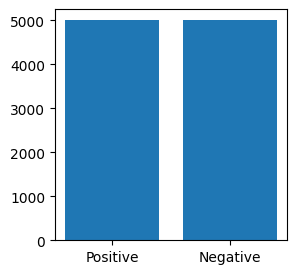

In [ ]:
fig = plt.figure(figsize=(3, 3))

labels = 'Positive', 'Negative'

sizes = [y_positive, y_negative]

plt.bar(labels,sizes)

plt.show()

In [ ]:
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

In [ ]:
import re
#remove old style retweet text "RT"
tweet2=re.sub(r'^RT[\s]+','',tweet1["Tweets"])

#remove hyperlinks
tweet2=re.sub(r'https?://.*[\r\n]*','',tweet2)

#remove hashtags
#only removing the hash # sign from the word
tweet2=re.sub(r'#','',tweet2)
tweet2=re.sub(r'@\w+','',tweet2)
tweet2=re.sub(r'[:)|(:)]','',tweet2)
print(tweet1["Tweets"])
print("\n Cleaned tweet\n", tweet2)

Achieving excellence in Music as a Music Producer is a Mind Boggling &amp; Fatiguing Job... Baareeq... :) :) :)

 Cleaned tweet
 Achieving excellence in Music as a Music Producer is a Mind Boggling &amp; Fatiguing Job... Baareeq...   


In [ ]:
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:\n')
print(tweet_tokens)


Tokenized string:

['achieving', 'excellence', 'in', 'music', 'as', 'a', 'music', 'producer', 'is', 'a', 'mind', 'boggling', '&', 'fatiguing', 'job', '...', 'baareeq', '...']


In [ ]:
from nltk.corpus import stopwords
import string
nltk.download('stopwords')
stopwords_english = stopwords.words('english')
print('stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopwords_english = stopwords.words('english')
print('stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [ ]:
print(tweet_tokens)
print()
# print('\033[94m')
tweet_clean=[]
for word in tweet_tokens:
    if (word not in stopwords_english and word not in string.punctuation):
        tweet_clean.append(word)
print('removed stop word and punctuation')
print(tweet_clean)

['achieving', 'excellence', 'in', 'music', 'as', 'a', 'music', 'producer', 'is', 'a', 'mind', 'boggling', '&', 'fatiguing', 'job', '...', 'baareeq', '...']

removed stop word and punctuation
['achieving', 'excellence', 'music', 'music', 'producer', 'mind', 'boggling', 'fatiguing', 'job', '...', 'baareeq', '...']


In [ ]:
def process_tweet(tweet):
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+','',tweet)

    # remove hyperlinks
    tweet = re.sub(r'https?://.*[\r\n]*','',tweet)

    # remove hashtags and mentions
    tweet = re.sub(r'#','',tweet)
    tweet = re.sub(r'@\w+','',tweet)

    # remove colons and parentheses (if intended as part of cleaning, otherwise remove this line)
    tweet = re.sub(r'[:)|(:)]','',tweet)

    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean=[]
    for word in tweet_tokens:
        if (word not in stopwords_english and word not in string.punctuation):
            tweets_clean.append(word)
    return tweets_clean

In [ ]:
tweet1=all_tweets.iloc[100]
tweet=tweet1["Tweets"]
print(process_tweet(tweet))

['achieving', 'excellence', 'music', 'music', 'producer', 'mind', 'boggling', 'fatiguing', 'job', '...', 'baareeq', '...']


In [ ]:
print("Name:Affan Ansari, UIN:231A023\n")
processed_tweets=all_tweets['Tweets'].apply(process_tweet)
all_tweets['Tweets_processed']=processed_tweets
pd.set_option('display.max_colwidth', None)
all_tweets

Name:Affan Ansari, UIN:231A023



,Tweets,Sentiment,Tweets_processed
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",Negative,"[love, feel, emm, think]"
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),Positive,"[thanks, guys]"
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",Positive,"[love, lord, better, life, <3]"
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,Positive,"[yeah, better, use, official, account, like, ❤, ️]"
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,Positive,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]"
...,...,...,...
9995,My nose and forehead are peeling :(,Negative,"[nose, forehead, peeling]"
9996,@LittleMix come to Belgium :(,Negative,"[come, belgium]"
9997,WHY MUST THE VIDEO STOP THO :(,Negative,"[must, video, stop, tho]"
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),Positive,"[like, amazing, donut, recipe, share, foiegras, lovers]"
